# 02 — Markov Chain Risk Model

## Goal

Calibrate a discrete-time Markov chain for customer risk-state transitions and derive per-customer risk parameters for the optimiser:

$$EV_i = 40 - PD_i \times LGD_i \times EAD_i$$

| Input | Source |
|-------|--------|
| `df_features.csv` | Notebook 01 (EDA) |
| Transition matrix **T** | Calibrated below |

| Output | Used in |
|--------|---------|
| `df_risk.csv` | Notebooks 03–05 |

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

ROOT = Path().cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

from markov_risk import (
    DEFAULT_T, STATES, TIER_COLORS,
    TRANSITION_MATRICES, SCENARIO_REFERENCES, get_transition_matrix,
    validate, annual_pd, stationary, project,
    assign_params, sensitivity,
    plot_transition, plot_annual_pd, plot_projection,
    plot_ev_distribution, plot_sensitivity,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df = pd.read_csv(ROOT / 'data' / 'df_features.csv')
print(f'Loaded {len(df):,} rows  |  Columns: {len(df.columns)}')
print(f'Risk tiers: {df["risk_label"].value_counts().to_dict()}')

Loaded 30,000 rows  |  Columns: 13
Risk tiers: {'Near-Prime': 15103, 'Prime': 7520, 'Sub-Prime': 7377}


---
## 1. Transition Matrix

Four states: **Prime** (otp ≥ 95%), **Near-Prime** (85–95%), **Sub-Prime** (80–85%), **Default** (absorbing).

Monthly transition probabilities — calibrated for unsecured consumer micro-lending:

| From → Default | Monthly PD | Rationale |
|----------------|------------|-----------|
| Prime | 0.5% | Low risk, strong repayment history |
| Near-Prime | 1.5% | Moderate risk, occasional late payments |
| Sub-Prime | 5.0% | High risk, frequent delinquency |

Upgrades (e.g., Near-Prime → Prime at 4%/month) and downgrades are also modelled.

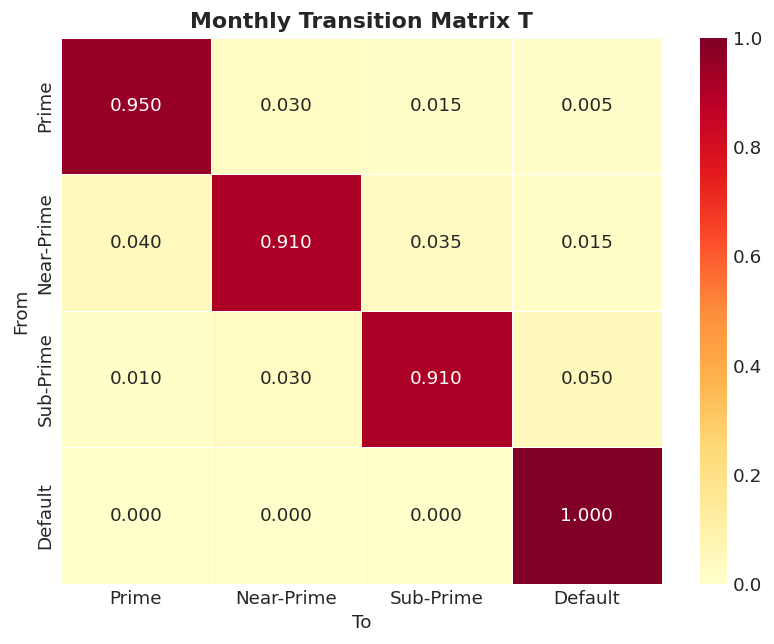

Scenario: base
References:
 - FRED DRCCLACBS (Delinquency Rate on Credit Card Loans)
 - FRED CORCCACBS (Charge-Off Rate on Credit Card Loans)

Monthly PD by tier:
  Prime       : 0.5%
  Near-Prime  : 1.5%
  Sub-Prime   : 5.0%


In [2]:
scenario = 'base'
T = get_transition_matrix(scenario)
validate(T)
plot_transition(T)

print(f'Scenario: {scenario}')
print('References:')
print(' -', SCENARIO_REFERENCES['source_1'])
print(' -', SCENARIO_REFERENCES['source_2'])

print('\nMonthly PD by tier:')
for i, s in enumerate(STATES[:3]):
    print(f'  {s:<12}: {T[i, 3]:.1%}')

### 1.1 Alternative Calibrations (soft / base / conservative)

We use two public benchmark references:
- `FRED DRCCLACBS` — Delinquency Rate on Credit Card Loans
- `FRED CORCCACBS` — Charge-Off Rate on Credit Card Loans

From these anchors, we define three monthly PD scenarios (in [src/markov_risk.py](src/markov_risk.py)):
- `soft`: easier credit environment
- `base`: central calibration
- `conservative`: stress / adverse environment

Important: these are benchmark-anchored calibrations, not direct one-to-one estimates from our dataset.

In [3]:
rows = []
for name in ['soft', 'base', 'conservative']:
    T_s = get_transition_matrix(name)
    p = annual_pd(T_s)
    tmp = assign_params(df, T_s, lgd=0.55, ead_pct=0.50, profit=40)
    rows.append({
        'scenario': name,
        'pd_m_prime': T_s[0, 3],
        'pd_m_near': T_s[1, 3],
        'pd_m_sub': T_s[2, 3],
        'pd_a_prime': p[0],
        'pd_a_near': p[1],
        'pd_a_sub': p[2],
        'ev_pos_pct': (tmp['ev_per_increase'] > 0).mean(),
        'avg_ev': tmp['ev_per_increase'].mean(),
    })

scn = pd.DataFrame(rows)
for c in [c for c in scn.columns if c.startswith('pd_') or c.endswith('_pct')]:
    scn[c] = scn[c] * 100

display(scn.round(2))

,scenario,pd_m_prime,pd_m_near,pd_m_sub,pd_a_prime,pd_a_near,pd_a_sub,ev_pos_pct,avg_ev
0,soft,0.35,1.2,4.0,8.15,15.89,33.88,92.42,27.31
1,base,0.50,1.5,5.0,10.56,19.49,40.43,88.46,24.02
2,conservative,0.75,2.2,7.0,14.83,26.73,51.74,83.84,17.15


---
## 2. Annual PD & Portfolio Projection

Annual PD is computed as the probability of reaching `Default` within 12 months via the transition matrix:

$$T_{12} = T^{12}, \quad PD_{annual}(s) = T_{12}[s, Default]$$

Where the reported values come from:
- `Prime`: $T_{12}[Prime, Default] = 10.6\%$
- `Near-Prime`: $T_{12}[Near\text{-}Prime, Default] = 19.5\%$
- `Sub-Prime`: $T_{12}[Sub\text{-}Prime, Default] = 40.4\%$

Important: this is not `12 × monthly PD`, and it does not generally equal $1-(1-PD_{monthly})^{12}$,
because the model includes migrations between risk states (upgrades/downgrades).

Initial portfolio: **25% Prime, 50% Near-Prime, 25% Sub-Prime** (from EDA — Uniform `on_time_pct` on [80, 100]).

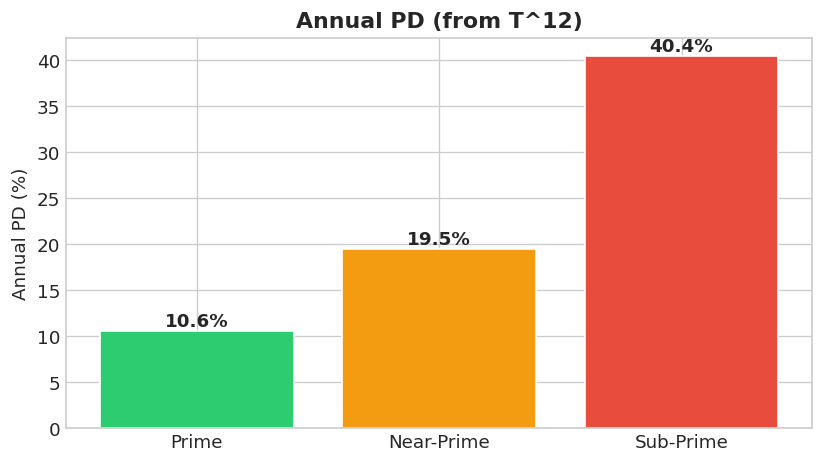

Annual PD:
  Prime       : 10.6%
  Near-Prime  : 19.5%
  Sub-Prime   : 40.4%


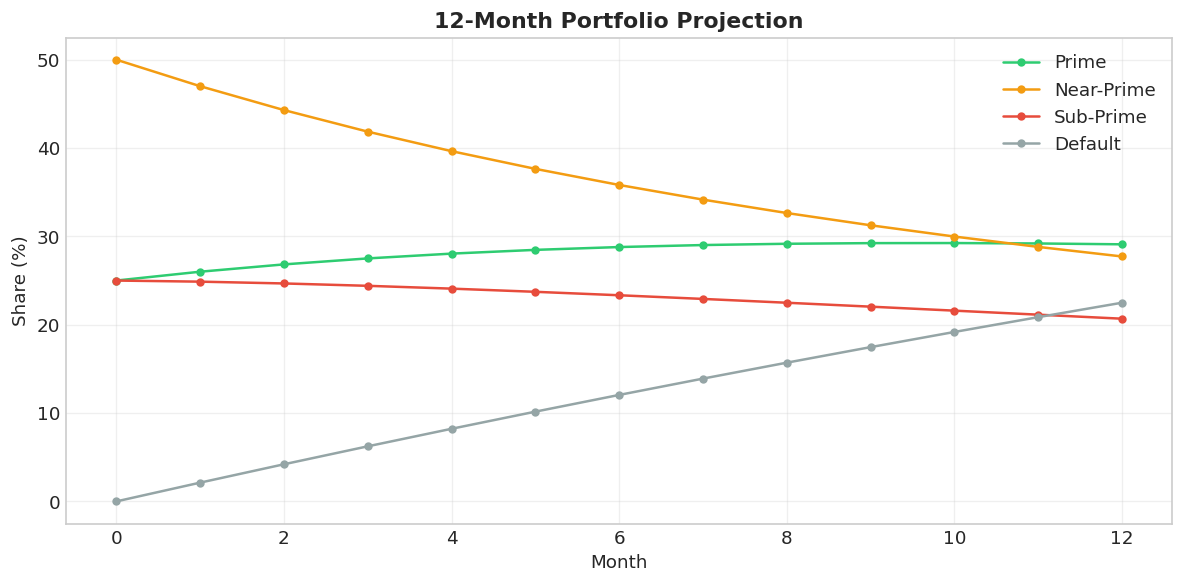


Stationary distribution:
  Prime       : 0.0%
  Near-Prime  : 0.0%
  Sub-Prime   : 0.0%
  Default     : 100.0%

Month-12 portfolio:
  Prime       : 29.1%
  Near-Prime  : 27.7%
  Sub-Prime   : 20.7%
  Default     : 22.5%


In [3]:
pds = plot_annual_pd(T)
print('Annual PD:')
for s, p in zip(STATES[:3], pds):
    print(f'  {s:<12}: {p:.1%}')

pi0 = np.array([0.25, 0.50, 0.25, 0.00])
traj = project(T, pi0, steps=12)
plot_projection(traj)

pi_inf = stationary(T)
print('\nStationary distribution:')
for s, p in zip(STATES, pi_inf):
    print(f'  {s:<12}: {p:.1%}')

print(f'\nMonth-12 portfolio:')
for s, p in zip(STATES, traj[12]):
    print(f'  {s:<12}: {p:.1%}')

---
## 3. Risk Parameters per Customer

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| LGD | 55% | Unsecured consumer lending benchmark |
| EAD | 50% of `initial_loan` per increase | Limit increase proportional to credit line |
| Profit | $40 per increase | Assessment specification |

$$EV_i = 40 \;-\; pd\_monthly_i \times 0.55 \times (initial\_loan_i \times 0.50)$$

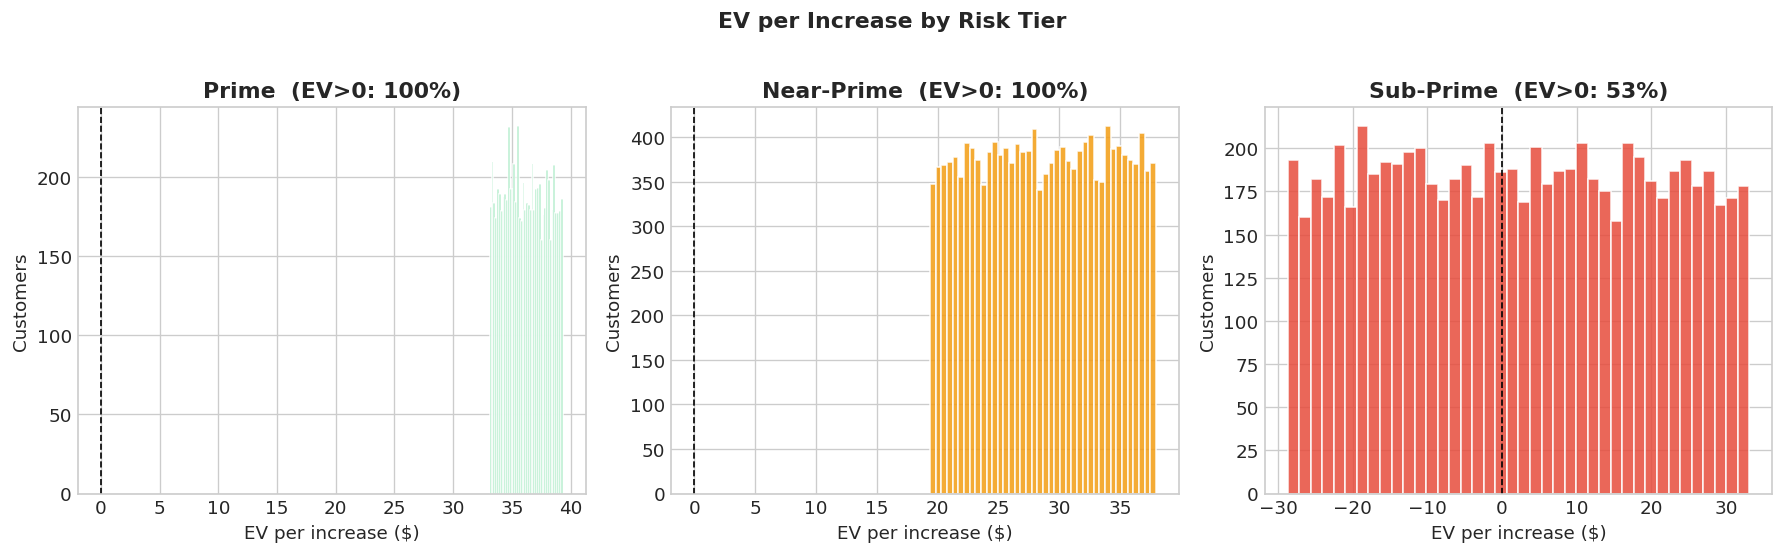

,n,avg_ev,pct_ev_pos,avg_el
risk_label,,,,
Prime,7520,36.191,1.000,3.809
Near-Prime,15103,28.701,1.000,11.299
Sub-Prime,7377,2.022,0.531,37.978



Customers with EV > 0: 26,537 / 30,000 (88.5%)


In [4]:
df = assign_params(df, T, lgd=0.55, ead_pct=0.50, profit=40)

plot_ev_distribution(df)

summary = (df.groupby('risk_label')
             .agg(n=('customer_id', 'count'),
                  avg_ev=('ev_per_increase', 'mean'),
                  pct_ev_pos=('ev_per_increase', lambda x: (x > 0).mean()),
                  avg_el=('el_per_increase', 'mean'))
             .reindex(['Prime', 'Near-Prime', 'Sub-Prime']))
display(summary.round(3))

n_pos = (df['ev_per_increase'] > 0).sum()
print(f'\nCustomers with EV > 0: {n_pos:,} / {len(df):,} ({n_pos/len(df)*100:.1f}%)')

---
## 4. Sensitivity Analysis

Sweep monthly PD ±2 pp from baseline. Observe impact on annual PD and per-increase EV.

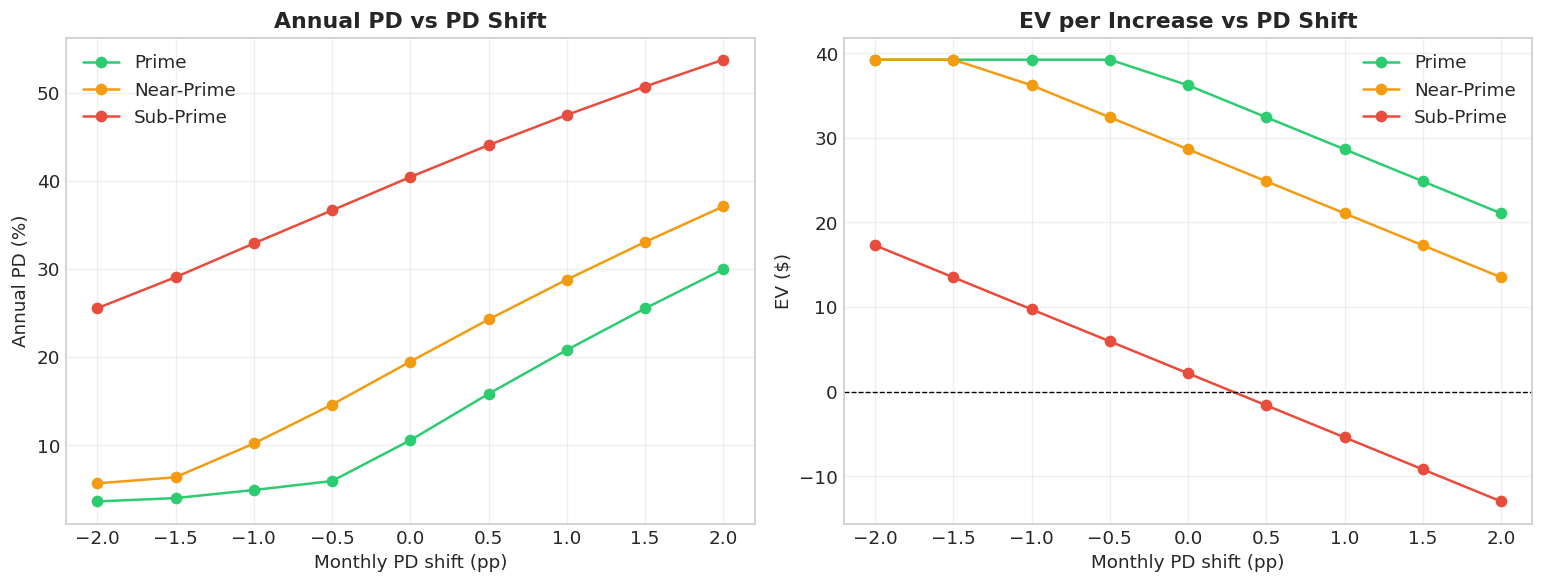

Prime: profitable across all tested shifts
Near-Prime: profitable across all tested shifts
Sub-Prime: unprofitable at shift >= +0.5 pp


In [5]:
sens = sensitivity(T, lgd=0.55, mean_ead=df['ead'].mean(), profit=40)
plot_sensitivity(sens)

for tier in STATES[:3]:
    s = sens[sens['tier'] == tier]
    neg = s[s['ev'] < 0]
    if len(neg):
        print(f'{tier}: unprofitable at shift >= {neg["shift_pp"].iloc[0]:+.1f} pp')
    else:
        print(f'{tier}: profitable across all tested shifts')

---
## 5. Key Takeaways

1. **Markov chain** monthly PD: Prime 0.5%, Near-Prime 1.5%, Sub-Prime 5.0%
2. **Annual PD** (multi-step via $T^{12}$) is significantly higher due to degradation paths
3. **EV per increase** varies by both risk tier AND loan size — high-loan Sub-Prime customers are loss-making
4. **Sensitivity**: results robust to ±1 pp shift; Sub-Prime becomes entirely unprofitable at ~+2 pp

`df_risk.csv` feeds into Notebooks 03 (Demand Forecasting) and 04 (Optimisation).

In [6]:
out = ROOT / 'data' / 'df_risk.csv'
df.to_csv(out, index=False)
print(f'Saved: {out}')
print(f'Shape: {df.shape}')
print(f'New columns: pd_monthly, pd_annual, lgd, ead, el_per_increase, ev_per_increase')

Saved: /data/aturov/loan_limit_increases/data/df_risk.csv
Shape: (30000, 19)
New columns: pd_monthly, pd_annual, lgd, ead, el_per_increase, ev_per_increase
